# Phân tích Khám phá Dữ liệu (EDA) — Online Retail Dataset

Bộ dữ liệu ghi lại các giao dịch bán lẻ trực tuyến của một công ty tại Anh, trong khoảng thời gian **01/12/2010 – 09/12/2011**. Mỗi dòng là một dòng hóa đơn (invoice line), gồm mã hóa đơn, mã sản phẩm, mô tả, số lượng, ngày giao dịch, đơn giá, mã khách hàng và quốc gia.

**Mục tiêu của notebook:**
1. Tổng quan cấu trúc dữ liệu, kiểu dữ liệu, giá trị thiếu
2. Làm sạch và phát hiện bất thường (giao dịch hủy, giá trị âm/0)
3. Phân tích phân phối các biến số (Quantity, UnitPrice)
4. Phân tích theo thời gian (xu hướng, mùa vụ)
5. Phân tích theo quốc gia, sản phẩm, khách hàng
6. Tổng kết insight chính

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## 1. Tải dữ liệu và tổng quan cấu trúc

In [2]:
df = pd.read_csv("data.csv", encoding="ISO-8859-1")
print("Kích thước dữ liệu:", df.shape)
df.head()

Kích thước dữ liệu: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
InvoiceNo,541909,25900,573585,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.0,NaN,NaN,NaN,9.55225,218.081158,-80995.0,1.0,3.0,10.0,80995.0
InvoiceDate,541909,23260,10/31/2011 14:41,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UnitPrice,541909.0,NaN,NaN,NaN,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,NaN,NaN,NaN,15287.69057,1713.600303,12346.0,13953.0,15152.0,16791.0,18287.0
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Nhận xét ban đầu:**
- Dữ liệu có 541,909 dòng, 8 cột.
- `InvoiceNo`, `StockCode` là dạng chuỗi (có lẫn ký tự, ví dụ `C...` cho đơn hủy, `POST` cho phí vận chuyển).
- `CustomerID` là số thực (có NaN — nhiều dòng không gắn với khách hàng cụ thể).
- `InvoiceDate` hiện là kiểu chuỗi, cần chuyển sang datetime.

## 2. Giá trị thiếu (Missing values)

In [5]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_df[missing_df["missing_count"] > 0]

,missing_count,missing_pct
Description,1454,0.27
CustomerID,135080,24.93


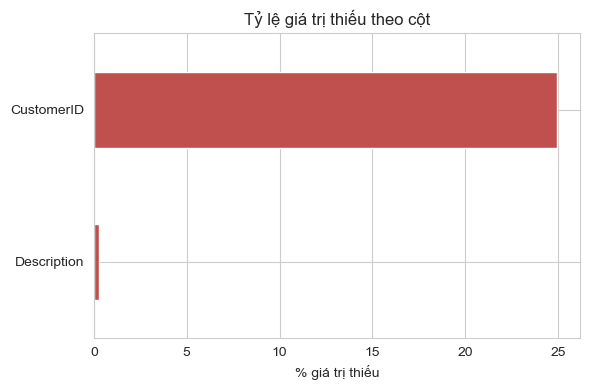

In [6]:
fig, ax = plt.subplots(figsize=(6,4))
missing_df[missing_df["missing_count"]>0]["missing_pct"].plot(kind="barh", ax=ax, color="#c0504d")
ax.set_xlabel("% giá trị thiếu")
ax.set_title("Tỷ lệ giá trị thiếu theo cột")
plt.tight_layout()
plt.show()

**Nhận xét:**
- `CustomerID` thiếu ~24.9% — đây là các giao dịch không xác định được khách hàng (có thể là bán tại quầy/khách vãng lai). Cần cân nhắc loại bỏ khi phân tích theo khách hàng (RFM, customer segmentation).
- `Description` thiếu rất ít (~0.27%), có thể loại bỏ hoặc điền giá trị "Unknown".

## 3. Làm sạch dữ liệu & phát hiện bất thường

In [7]:
df = df.drop_duplicates()
df = df.dropna(subset=["Description"])
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [8]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["InvoiceNo"] = df["InvoiceNo"].astype(str)
df["is_cancelled"] = df["InvoiceNo"].str.startswith("C")

n_cancelled = df["is_cancelled"].sum()
print(f"Số dòng là giao dịch HỦY (InvoiceNo bắt đầu bằng 'C'): {n_cancelled} ({n_cancelled/len(df)*100:.2f}%)")

n_neg_qty = (df["Quantity"] < 0).sum()
n_zero_price = (df["UnitPrice"] == 0).sum()
n_neg_price = (df["UnitPrice"] < 0).sum()
print(f"Số dòng có Quantity < 0: {n_neg_qty}")
print(f"Số dòng có UnitPrice = 0: {n_zero_price}")
print(f"Số dòng có UnitPrice < 0: {n_neg_price}")

Số dòng là giao dịch HỦY (InvoiceNo bắt đầu bằng 'C'): 9251 (1.73%)
Số dòng có Quantity < 0: 9725
Số dòng có UnitPrice = 0: 1056
Số dòng có UnitPrice < 0: 2


In [33]:
df_1 = df[df['CustomerID'].isna()]
df_1["InvoiceDate"] = pd.to_datetime(df_1["InvoiceDate"])
df_1["InvoiceNo"] = df_1["InvoiceNo"].astype(str)
df_1["is_cancelled"] = df_1["InvoiceNo"].str.startswith("C")

n_cancelled = df_1["is_cancelled"].sum()
print(f"Số dòng là giao dịch HỦY (InvoiceNo bắt đầu bằng 'C'): {n_cancelled} ({n_cancelled/len(df_1)*100:.2f}%)")

n_neg_qty = (df_1["Quantity"] < 0).sum()
n_zero_price = (df_1["UnitPrice"] == 0).sum()
n_neg_price = (df_1["UnitPrice"] < 0).sum()
print(f"Số dòng có Quantity < 0: {n_neg_qty}")
print(f"Số dòng có UnitPrice = 0: {n_zero_price}")
print(f"Số dòng có UnitPrice < 0: {n_neg_price}")

Số dòng là giao dịch HỦY (InvoiceNo bắt đầu bằng 'C'): 379 (0.28%)
Số dòng có Quantity < 0: 853
Số dòng có UnitPrice = 0: 1016
Số dòng có UnitPrice < 0: 2


C:\Users\PHUC\AppData\Local\Temp\ipykernel_1392\3113805785.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_1["InvoiceDate"] = pd.to_datetime(df_1["InvoiceDate"])
C:\Users\PHUC\AppData\Local\Temp\ipykernel_1392\3113805785.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_1["InvoiceNo"] = df_1["InvoiceNo"].astype(str)
C:\Users\PHUC\AppData\Local\Temp\ipykernel_1392\3113805785.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexe

In [28]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Revenue
count,535187.000000,535187,535187.000000,401604.000000,535187.000000
mean,9.671593,2011-07-04 11:43:44.485273600,4.645242,15281.160818,18.173100
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,-168469.600000
25%,1.000000,2011-03-28 11:34:00,1.250000,13939.000000,3.750000
50%,3.000000,2011-07-19 15:38:00,2.080000,15145.000000,9.900000
75%,10.000000,2011-10-19 08:20:00,4.130000,16784.000000,17.400000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,168469.600000
std,219.059056,NaN,97.364810,1714.006089,381.171824


In [32]:
df[df['Quantity'] == 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,is_cancelled,Revenue


In [ ]:
df_new = df.dropna()

In [30]:
df_new.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Revenue
count,401604.000000,401604,401604.000000,401604.000000,401604.000000
mean,12.183273,2011-07-10 12:08:23.848567552,3.474064,15281.160818,20.613638
min,-80995.000000,2010-12-01 08:26:00,0.000000,12346.000000,-168469.600000
25%,2.000000,2011-04-06 15:02:00,1.250000,13939.000000,4.250000
50%,5.000000,2011-07-29 15:40:00,1.950000,15145.000000,11.700000
75%,12.000000,2011-10-20 11:58:30,3.750000,16784.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,168469.600000
std,250.283037,NaN,69.764035,1714.006089,430.352218


In [31]:
df_new[df_new['Quantity'] == 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,is_cancelled,Revenue


In [9]:
# Các dòng có Quantity âm nhưng không phải hóa đơn hủy
negative_not_cancelled = df.loc[
    (df["Quantity"] < 0) & (~df["is_cancelled"])
].copy()

# Description của nhóm này là ghi chú nghiệp vụ, nên dùng để suy luận nguyên nhân.
description_lower = negative_not_cancelled["Description"].str.strip().str.lower()
reason_rules = [
    ("Hư hỏng / không thể bán", r"damag|dagam|fault|mould|wet|rust|smash|crush|crack|broken|breakage|unsaleable|throw|thrown|printing"),
    ("Bán online / sai quy cách đóng gói", r"dotcom|amazon|ebay|sold as|sold in"),
    ("Thiếu / thất lạc / chưa nhận", r"missing|lost|mia|can't find|not rcvd"),
    ("Sai mã / nhãn / ghi nhận", r"wrong|incorrect|barcode|mix(?:ed)? up|marked|mrked|coded|credit"),
    ("Kiểm kê / điều chỉnh tồn kho", r"check|adjust|counted|stock|historic|found|test"),
    ("Mẫu / trưng bày / cho tặng", r"sample|showroom|display|given away"),
]
negative_not_cancelled["reason_group"] = np.select(
    [description_lower.str.contains(pattern, regex=True, na=False) for _, pattern in reason_rules],
    [label for label, _ in reason_rules],
    default="Không rõ (mô tả không đủ thông tin)",
)

reason_summary = (
    negative_not_cancelled.groupby("reason_group", as_index=False)
    .agg(so_dong=("InvoiceNo", "size"), tong_quantity_am=("Quantity", "sum"))
    .sort_values("so_dong", ascending=False)
)
reason_summary["ty_le_pct"] = (reason_summary["so_dong"] / len(negative_not_cancelled) * 100).round(2)

print(f"Số dòng Quantity < 0 nhưng InvoiceNo không bắt đầu bằng 'C': {len(negative_not_cancelled)}")
print(f"Số dòng có UnitPrice = 0: {(negative_not_cancelled['UnitPrice'] == 0).sum()}")
print(f"Số dòng thiếu CustomerID: {negative_not_cancelled['CustomerID'].isna().sum()}")
print("\nNhóm nguyên nhân suy luận từ Description:")
display(reason_summary)

print("Chi tiết từng Description (giữ nguyên ghi chú gốc):")
display(
    negative_not_cancelled.groupby(["reason_group", "Description"], as_index=False)
    .agg(so_dong=("InvoiceNo", "size"), tong_quantity_am=("Quantity", "sum"))
    .sort_values(["reason_group", "so_dong"], ascending=[True, False])
)

# Hiển thị đủ 474 dòng để đối chiếu khi cần.
with pd.option_context("display.max_rows", None):
    display(negative_not_cancelled.sort_values(["reason_group", "Description", "InvoiceDate"]))

Số dòng Quantity < 0 nhưng InvoiceNo không bắt đầu bằng 'C': 474
Số dòng có UnitPrice = 0: 474
Số dòng thiếu CustomerID: 474

Nhóm nguyên nhân suy luận từ Description:


,reason_group,so_dong,tong_quantity_am,ty_le_pct
1,Hư hỏng / không thể bán,186,-92265,39.24
3,Kiểm kê / điều chỉnh tồn kho,140,-17147,29.54
2,Không rõ (mô tả không đủ thông tin),51,-13614,10.76
0,Bán online / sai quy cách đóng gói,47,-10622,9.92
5,Sai mã / nhãn / ghi nhận,25,-16929,5.27
6,Thiếu / thất lạc / chưa nhận,19,-8490,4.01
4,Mẫu / trưng bày / cho tặng,6,-1734,1.27


Chi tiết từng Description (giữ nguyên ghi chú gốc):


,reason_group,Description,so_dong,tong_quantity_am
16,Bán online / sai quy cách đóng gói,sold as set on dotcom,20,-2393
11,Bán online / sai quy cách đóng gói,ebay,5,-37
4,Bán online / sai quy cách đóng gói,Dotcom sales,2,-200
8,Bán online / sai quy cách đóng gói,dotcom,2,-49
13,Bán online / sai quy cách đóng gói,sold as 1,2,-684
...,...,...,...,...
132,Thiếu / thất lạc / chưa nhận,can't find,1,-125
133,Thiếu / thất lạc / chưa nhận,lost,1,-1050
134,Thiếu / thất lạc / chưa nhận,lost in space,1,-98
135,Thiếu / thất lạc / chưa nhận,lost??,1,-1131


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,is_cancelled,reason_group
114539,546024,85175,? sold as sets?,-1200,2011-03-08 17:31:00,0.0,NaN,United Kingdom,False,Bán online / sai quy cách đóng gói
114540,546025,85172,?sold as sets?,-600,2011-03-08 17:31:00,0.0,NaN,United Kingdom,False,Bán online / sai quy cách đóng gói
114534,546020,85175,Amazon sold sets,-210,2011-03-08 17:27:00,0.0,NaN,United Kingdom,False,Bán online / sai quy cách đóng gói
65077,541687,46000S,Dotcom,-300,2011-01-20 15:42:00,0.0,NaN,United Kingdom,False,Bán online / sai quy cách đóng gói
22296,538161,46000S,Dotcom sales,-100,2010-12-09 17:25:00,0.0,NaN,United Kingdom,False,Bán online / sai quy cách đóng gói
22297,538162,46000M,Dotcom sales,-100,2010-12-09 17:25:00,0.0,NaN,United Kingdom,False,Bán online / sai quy cách đóng gói
114493,546016,85172,Dotcom set,-675,2011-03-08 17:21:00,0.0,NaN,United Kingdom,False,Bán online / sai quy cách đóng gói
140199,548380,22127,Dotcom sold in 6's,-60,2011-03-30 16:44:00,0.0,NaN,United Kingdom,False,Bán online / sai quy cách đóng gói
289689,562278,21391,Sold as 1 on dotcom,-342,2011-08-04 10:27:00,0.0,NaN,United Kingdom,False,Bán online / sai quy cách đóng gói
492659,578145,22579,dotcom,-40,2011-11-23 11:07:00,0.0,NaN,United Kingdom,False,Bán online / sai quy cách đóng gói


In [10]:
# Phân tích các dòng UnitPrice = 0 còn lại sau khi loại 474 dòng ở cell trên
zero_price_remaining = df.loc[
    (df["UnitPrice"] == 0)
    & ~((df["Quantity"] < 0) & (~df["is_cancelled"]))
].copy()

# Xem trong cùng InvoiceNo có mặt hàng nào thực sự được tính giá hay không.
invoice_has_paid_line = (
    df["UnitPrice"].gt(0).groupby(df["InvoiceNo"]).transform("any")
)
zero_price_remaining["invoice_has_paid_line"] = invoice_has_paid_line.loc[zero_price_remaining.index]
has_customer = zero_price_remaining["CustomerID"].notna()
has_paid_line = zero_price_remaining["invoice_has_paid_line"]

# Đây là nhóm nguyên nhân suy luận từ ngữ cảnh hóa đơn, không phải nhãn có sẵn trong dữ liệu.
zero_price_remaining["zero_price_reason"] = np.select(
    [
        has_customer & has_paid_line,
        (~has_customer) & has_paid_line,
        (~has_customer) & (~has_paid_line),
        has_customer & (~has_paid_line),
    ],
    [
        "Có CustomerID, cùng hóa đơn có hàng trả tiền: có thể là hàng tặng/khuyến mại hoặc bỏ sót giá",
        "Thiếu CustomerID, cùng hóa đơn có hàng trả tiền: chưa đủ dữ kiện để phân biệt hàng tặng và thiếu giá",
        "Thiếu CustomerID, toàn hóa đơn giá 0: chủ yếu là điều chỉnh kho/nội bộ",
        "Có CustomerID nhưng toàn hóa đơn giá 0: bất thường, cần kiểm tra thủ công",
    ],
    default="Chưa xác định",
)

zero_price_summary = (
    zero_price_remaining.groupby("zero_price_reason", as_index=False)
    .agg(
        so_dong=("InvoiceNo", "size"),
        so_hoa_don=("InvoiceNo", "nunique"),
        tong_quantity=("Quantity", "sum"),
    )
    .sort_values("so_dong", ascending=False)
)
zero_price_summary["ty_le_pct"] = (
    zero_price_summary["so_dong"] / len(zero_price_remaining) * 100
).round(2)

print(f"Tổng số dòng UnitPrice = 0: {(df['UnitPrice'] == 0).sum()}")
print(f"Đã phân tích ở cell trên (Quantity < 0, không phải đơn hủy): {len(negative_not_cancelled)}")
print(f"Số dòng UnitPrice = 0 còn lại: {len(zero_price_remaining)}")
print(f"Tất cả {len(zero_price_remaining)} dòng còn lại có Quantity > 0: {(zero_price_remaining['Quantity'] > 0).all()}")
print("\nPhân nhóm theo ngữ cảnh hóa đơn:")
display(zero_price_summary)

print("Chi tiết Description trong từng nhóm:")
display(
    zero_price_remaining.groupby(["zero_price_reason", "Description"], as_index=False)
    .agg(so_dong=("InvoiceNo", "size"), tong_quantity=("Quantity", "sum"))
    .sort_values(["zero_price_reason", "so_dong"], ascending=[True, False])
)

# Hiển thị đủ 582 dòng để có thể kiểm tra từng trường hợp.
with pd.option_context("display.max_rows", None):
    display(
        zero_price_remaining.sort_values(
            ["zero_price_reason", "InvoiceNo", "Description"]
        )
    )

Tổng số dòng UnitPrice = 0: 1056
Đã phân tích ở cell trên (Quantity < 0, không phải đơn hủy): 474
Số dòng UnitPrice = 0 còn lại: 582
Tất cả 582 dòng còn lại có Quantity > 0: True

Phân nhóm theo ngữ cảnh hóa đơn:


,zero_price_reason,so_dong,so_hoa_don,tong_quantity,ty_le_pct
2,"Thiếu CustomerID, cùng hóa đơn có hàng trả tiề...",362,23,1266,62.20
3,"Thiếu CustomerID, toàn hóa đơn giá 0: chủ yếu ...",180,170,24900,30.93
1,"Có CustomerID, cùng hóa đơn có hàng trả tiền: ...",33,30,751,5.67
0,Có CustomerID nhưng toàn hóa đơn giá 0: bất th...,7,4,13133,1.20


Chi tiết Description trong từng nhóm:


,zero_price_reason,Description,so_dong,tong_quantity
0,Có CustomerID nhưng toàn hóa đơn giá 0: bất th...,36 FOIL STAR CAKE CASES,1,144
1,Có CustomerID nhưng toàn hóa đơn giá 0: bất th...,ASSTD DESIGN 3D PAPER STICKERS,1,12540
2,Có CustomerID nhưng toàn hóa đơn giá 0: bất th...,FAIRY CAKES NOTEBOOK A6 SIZE,1,16
3,Có CustomerID nhưng toàn hóa đơn giá 0: bất th...,Manual,1,1
4,Có CustomerID nhưng toàn hóa đơn giá 0: bất th...,POLKADOT RAIN HAT,1,144
...,...,...,...,...
250,"Thiếu CustomerID, toàn hóa đơn giá 0: chủ yếu ...",wrongly coded 20713,1,800
251,"Thiếu CustomerID, toàn hóa đơn giá 0: chủ yếu ...",wrongly coded 23343,1,1000
252,"Thiếu CustomerID, toàn hóa đơn giá 0: chủ yếu ...",wrongly marked,1,48
253,"Thiếu CustomerID, toàn hóa đơn giá 0: chủ yếu ...",wrongly marked 23343,1,200


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,is_cancelled,invoice_has_paid_line,zero_price_reason
86789,543599,84535B,FAIRY CAKES NOTEBOOK A6 SIZE,16,2011-02-10 13:08:00,0.0,17560.0,United Kingdom,False,False,Có CustomerID nhưng toàn hóa đơn giá 0: bất th...
314747,564651,22955,36 FOIL STAR CAKE CASES,144,2011-08-26 14:19:00,0.0,14646.0,Netherlands,False,False,Có CustomerID nhưng toàn hóa đơn giá 0: bất th...
314748,564651,21786,POLKADOT RAIN HAT,144,2011-08-26 14:19:00,0.0,14646.0,Netherlands,False,False,Có CustomerID nhưng toàn hóa đơn giá 0: bất th...
314746,564651,23268,SET OF 2 CERAMIC CHRISTMAS REINDEER,192,2011-08-26 14:19:00,0.0,14646.0,Netherlands,False,False,Có CustomerID nhưng toàn hóa đơn giá 0: bất th...
314745,564651,23270,SET OF 2 CERAMIC PAINTED HEARTS,96,2011-08-26 14:19:00,0.0,14646.0,Netherlands,False,False,Có CustomerID nhưng toàn hóa đơn giá 0: bất th...
361825,568384,M,Manual,1,2011-09-27 09:46:00,0.0,12748.0,United Kingdom,False,False,Có CustomerID nhưng toàn hóa đơn giá 0: bất th...
502122,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,2011-11-25 15:57:00,0.0,13256.0,United Kingdom,False,False,Có CustomerID nhưng toàn hóa đơn giá 0: bất th...
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,0.0,12647.0,Germany,False,True,"Có CustomerID, cùng hóa đơn có hàng trả tiền: ..."
33576,539263,22580,ADVENT CALENDAR GINGHAM SACK,4,2010-12-16 14:36:00,0.0,16560.0,United Kingdom,False,True,"Có CustomerID, cùng hóa đơn có hàng trả tiền: ..."
40089,539722,22423,REGENCY CAKESTAND 3 TIER,10,2010-12-21 13:45:00,0.0,14911.0,EIRE,False,True,"Có CustomerID, cùng hóa đơn có hàng trả tiền: ..."


In [11]:
# Xem kỹ 7 dòng có CustomerID nhưng toàn bộ hóa đơn đều có UnitPrice = 0
seven_zero_price_rows = zero_price_remaining.loc[
    zero_price_remaining["CustomerID"].notna()
    & (~zero_price_remaining["invoice_has_paid_line"])
].copy()

# 1. In 7 dòng gốc trước khi đưa ra bất kỳ nhận định nào.
original_columns = [
    "InvoiceNo", "StockCode", "Description", "Quantity",
    "InvoiceDate", "UnitPrice", "CustomerID", "Country",
]
print(f"Có {len(seven_zero_price_rows)} dòng thuộc {seven_zero_price_rows['InvoiceNo'].nunique()} hóa đơn:")
display(seven_zero_price_rows[original_columns])

# 2. So sánh với những lần bán có giá của cùng sản phẩm và cùng khách hàng.
valid_paid_sales = df.loc[
    (df["UnitPrice"] > 0) & (df["Quantity"] > 0) & (~df["is_cancelled"])
].copy()

product_price_reference = (
    valid_paid_sales.groupby("StockCode", as_index=False)
    .agg(
        so_lan_san_pham_duoc_ban_co_gia=("InvoiceNo", "size"),
        gia_trung_vi_san_pham=("UnitPrice", "median"),
        gia_thap_nhat=("UnitPrice", "min"),
        gia_cao_nhat=("UnitPrice", "max"),
        quantity_lon_nhat_da_ban_co_gia=("Quantity", "max"),
    )
)
customer_product_reference = (
    valid_paid_sales.groupby(["CustomerID", "StockCode"], as_index=False)
    .agg(
        so_lan_cung_khach_da_mua_co_gia=("InvoiceNo", "size"),
        gia_trung_vi_cung_khach=("UnitPrice", "median"),
        quantity_lon_nhat_cung_khach=("Quantity", "max"),
    )
)

seven_zero_price_evidence = (
    seven_zero_price_rows[original_columns]
    .merge(product_price_reference, on="StockCode", how="left")
    .merge(customer_product_reference, on=["CustomerID", "StockCode"], how="left")
)
seven_zero_price_evidence["gia_tri_uoc_tinh_theo_gia_trung_vi"] = (
    seven_zero_price_evidence["Quantity"]
    * seven_zero_price_evidence["gia_trung_vi_san_pham"]
).round(2)
seven_zero_price_evidence["quantity_gap_lan"] = (
    seven_zero_price_evidence["Quantity"]
    / seven_zero_price_evidence["quantity_lon_nhat_da_ban_co_gia"]
).round(2)

print("Bằng chứng đối chiếu với lịch sử bán hàng:")
display(seven_zero_price_evidence)

# 3. Nhận định theo từng hóa đơn; đây là suy luận từ dữ liệu, không phải lý do gốc được ghi sẵn.
invoice_findings = pd.DataFrame(
    [
        {
            "InvoiceNo": "543599",
            "nhan_dinh": (
                "Cùng khách 17560 đã mua đúng sản phẩm và số lượng 16 với giá 0.65 trước đó 8 ngày. "
                "Có thể là hàng bù/tặng, hoặc giá đã bị bỏ sót."
            ),
        },
        {
            "InvoiceNo": "564651",
            "nhan_dinh": (
                "Hóa đơn gồm 4 dòng giá 0, được tạo 2 phút sau hóa đơn 564650 của cùng khách 14646. "
                "Hai sản phẩm 23268 và 23270 lặp đúng số lượng nhưng ở hóa đơn trước có giá 1.25. "
                "Nhiều khả năng đây là hàng bổ sung miễn phí hoặc một hóa đơn bị thiếu giá."
            ),
        },
        {
            "InvoiceNo": "568384",
            "nhan_dinh": (
                "StockCode M và Description Manual cho thấy đây là dòng nhập thủ công/điều chỉnh, "
                "không phải một sản phẩm bán lẻ thông thường."
            ),
        },
        {
            "InvoiceNo": "578841",
            "nhan_dinh": (
                "Đây là giao dịch duy nhất của khách 13256 và Quantity = 12,540, trong khi mức lớn nhất "
                "từng bán có giá của sản phẩm này là 120. Khả năng cao là bút toán nội bộ hoặc lỗi dữ liệu, "
                "không giống một đơn hàng miễn phí thông thường."
            ),
        },
    ]
)
print("Nhận định theo từng hóa đơn:")
display(invoice_findings)

Có 7 dòng thuộc 4 hóa đơn:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
86789,543599,84535B,FAIRY CAKES NOTEBOOK A6 SIZE,16,2011-02-10 13:08:00,0.0,17560.0,United Kingdom
314745,564651,23270,SET OF 2 CERAMIC PAINTED HEARTS,96,2011-08-26 14:19:00,0.0,14646.0,Netherlands
314746,564651,23268,SET OF 2 CERAMIC CHRISTMAS REINDEER,192,2011-08-26 14:19:00,0.0,14646.0,Netherlands
314747,564651,22955,36 FOIL STAR CAKE CASES,144,2011-08-26 14:19:00,0.0,14646.0,Netherlands
314748,564651,21786,POLKADOT RAIN HAT,144,2011-08-26 14:19:00,0.0,14646.0,Netherlands
361825,568384,M,Manual,1,2011-09-27 09:46:00,0.0,12748.0,United Kingdom
502122,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,2011-11-25 15:57:00,0.0,13256.0,United Kingdom


Bằng chứng đối chiếu với lịch sử bán hàng:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,so_lan_san_pham_duoc_ban_co_gia,gia_trung_vi_san_pham,gia_thap_nhat,gia_cao_nhat,quantity_lon_nhat_da_ban_co_gia,so_lan_cung_khach_da_mua_co_gia,gia_trung_vi_cung_khach,quantity_lon_nhat_cung_khach,gia_tri_uoc_tinh_theo_gia_trung_vi,quantity_gap_lan
0,543599,84535B,FAIRY CAKES NOTEBOOK A6 SIZE,16,2011-02-10 13:08:00,0.0,17560.0,United Kingdom,156,0.65,0.42,1.49,144,1.0,0.650,16.0,10.40,0.11
1,564651,23270,SET OF 2 CERAMIC PAINTED HEARTS,96,2011-08-26 14:19:00,0.0,14646.0,Netherlands,128,1.45,1.25,2.92,192,2.0,1.250,192.0,139.20,0.50
2,564651,23268,SET OF 2 CERAMIC CHRISTMAS REINDEER,192,2011-08-26 14:19:00,0.0,14646.0,Netherlands,89,1.45,1.25,2.92,384,2.0,1.250,384.0,278.40,0.50
3,564651,22955,36 FOIL STAR CAKE CASES,144,2011-08-26 14:19:00,0.0,14646.0,Netherlands,136,2.10,0.79,4.21,144,2.0,1.850,48.0,302.40,1.00
4,564651,21786,POLKADOT RAIN HAT,144,2011-08-26 14:19:00,0.0,14646.0,Netherlands,231,0.79,0.32,0.85,144,NaN,NaN,NaN,113.76,1.00
5,568384,M,Manual,1,2011-09-27 09:46:00,0.0,12748.0,United Kingdom,316,1.95,0.06,4287.63,1600,14.0,0.925,183.0,1.95,0.00
6,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,2011-11-25 15:57:00,0.0,13256.0,United Kingdom,33,0.85,0.19,0.85,120,NaN,NaN,NaN,10659.00,104.50


Nhận định theo từng hóa đơn:


,InvoiceNo,nhan_dinh
0,543599,Cùng khách 17560 đã mua đúng sản phẩm và số lư...
1,564651,"Hóa đơn gồm 4 dòng giá 0, được tạo 2 phút sau ..."
2,568384,StockCode M và Description Manual cho thấy đây...
3,578841,Đây là giao dịch duy nhất của khách 13256 và Q...


In [12]:
# Kiểm tra: giao dịch hủy có trùng khớp với Quantity âm không?
pd.crosstab(df["is_cancelled"], df["Quantity"] < 0)

Quantity,False,True
is_cancelled,,
False,525462,474
True,0,9251


**Nhận xét:**
- Toàn bộ (hoặc gần như toàn bộ) giao dịch có `Quantity < 0` là giao dịch hủy (`InvoiceNo` bắt đầu bằng "C"). Đây là dữ liệu hợp lệ về mặt nghiệp vụ (hoàn/hủy đơn), không phải lỗi nhập liệu.
- Các dòng có `UnitPrice = 0` thường là hàng khuyến mãi/tặng hoặc điều chỉnh sổ sách — cần loại khi tính doanh thu.
- Với các phân tích về **doanh số bán ra thực tế**, nên tạo một tập dữ liệu đã lọc: loại giao dịch hủy và `UnitPrice <= 0`.

In [13]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

df_clean = df[(~df["is_cancelled"]) & (df["UnitPrice"] > 0) & (df["Quantity"] > 0)].copy()
print("Số dòng sau khi làm sạch:", df_clean.shape[0], f"({df_clean.shape[0]/len(df)*100:.1f}% dữ liệu gốc)")

Số dòng sau khi làm sạch: 524878 (98.1% dữ liệu gốc)


## 4. Phân phối các biến số chính (Quantity, UnitPrice, Revenue)

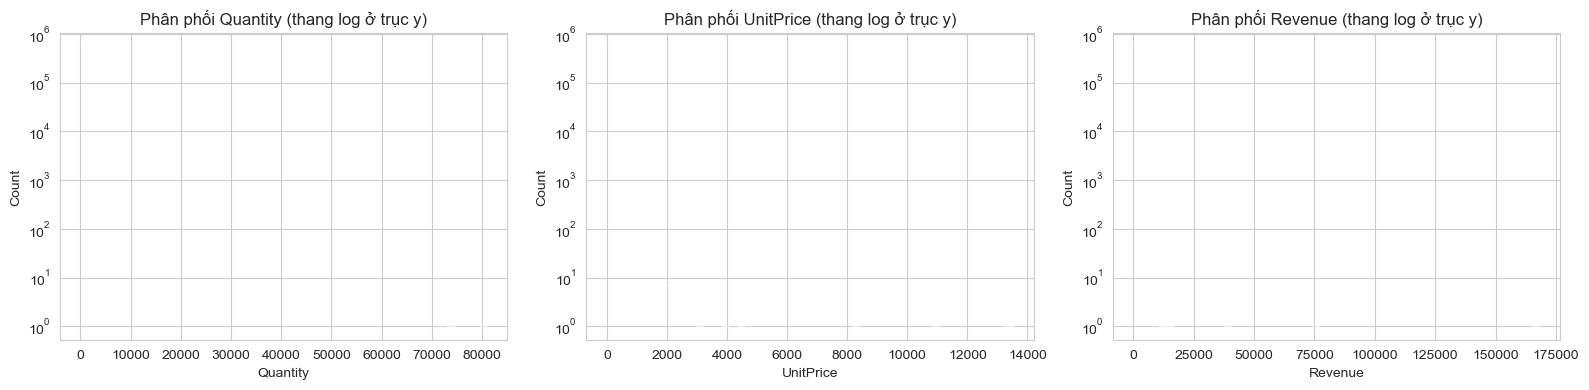

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))
for ax, col in zip(axes, ["Quantity", "UnitPrice", "Revenue"]):
    sns.histplot(df_clean[col], bins=50, ax=ax, kde=False, log_scale=(False, True))
    ax.set_title(f"Phân phối {col} (thang log ở trục y)")
plt.tight_layout()
plt.show()

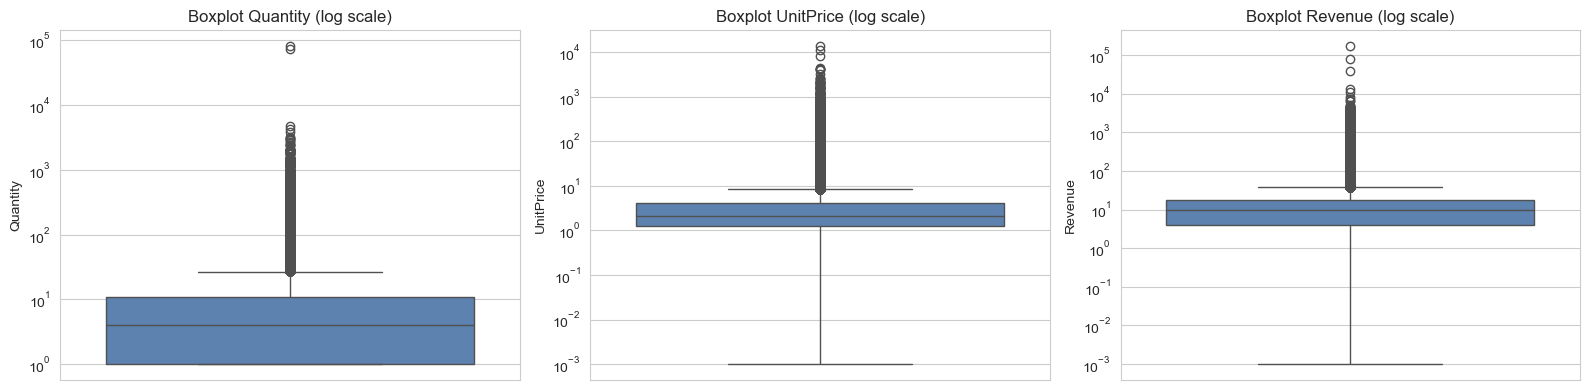

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))
for ax, col in zip(axes, ["Quantity", "UnitPrice", "Revenue"]):
    sns.boxplot(y=df_clean[col], ax=ax, color="#4f81bd")
    ax.set_yscale("log")
    ax.set_title(f"Boxplot {col} (log scale)")
plt.tight_layout()
plt.show()

In [16]:
df_clean[["Quantity", "UnitPrice", "Revenue"]].describe(percentiles=[.01,.25,.5,.75,.95,.99])

,Quantity,UnitPrice,Revenue
count,524878.000000,524878.000000,524878.000000
mean,10.616600,3.922573,20.275399
std,156.280031,36.093028,271.693566
min,1.000000,0.001000,0.001000
1%,1.000000,0.290000,0.550000
25%,1.000000,1.250000,3.900000
50%,4.000000,2.080000,9.920000
75%,11.000000,4.130000,17.700000
95%,30.000000,9.950000,59.800000
99%,100.000000,16.980000,183.600000


**Nhận xét:**
- Cả ba biến đều lệch phải rất mạnh (long-tail): phần lớn giao dịch có giá trị nhỏ, nhưng có một số ít giao dịch số lượng/giá trị cực lớn (ví dụ mua sỉ).
- Nên cân nhắc log-transform khi đưa các biến này vào mô hình thống kê hoặc dùng ngưỡng percentile (1%–99%) để loại outlier cực đoan nếu cần.

## 5. Phân tích theo thời gian

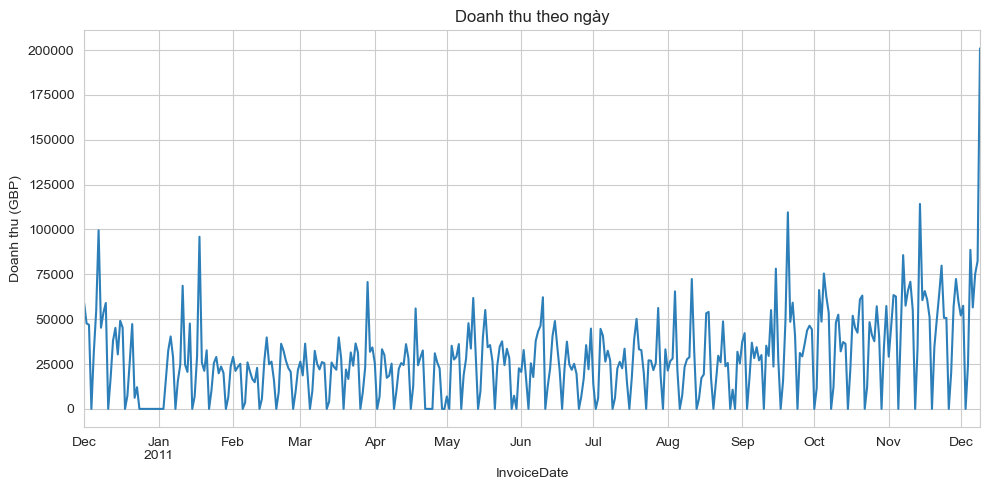

In [17]:
df_clean = df_clean.set_index("InvoiceDate")
daily = df_clean.resample("D").agg(Revenue=("Revenue","sum"), Orders=("InvoiceNo","nunique"))

fig, ax = plt.subplots()
daily["Revenue"].plot(ax=ax, color="#2c7fb8")
ax.set_title("Doanh thu theo ngày")
ax.set_ylabel("Doanh thu (GBP)")
plt.tight_layout()
plt.show()

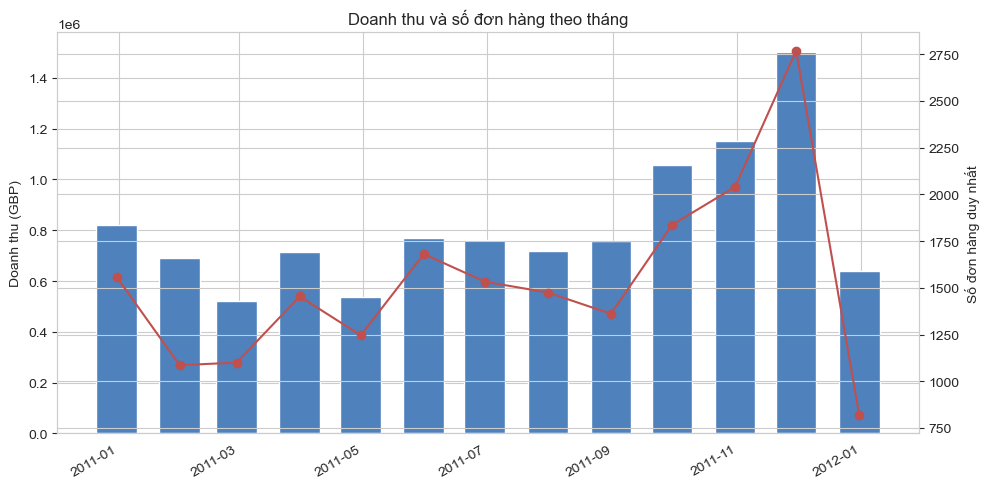

In [18]:
monthly = df_clean.resample("ME").agg(Revenue=("Revenue","sum"), Orders=("InvoiceNo","nunique"))

fig, ax1 = plt.subplots()
ax1.bar(monthly.index, monthly["Revenue"], width=20, color="#4f81bd", label="Doanh thu")
ax1.set_ylabel("Doanh thu (GBP)")
ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly["Orders"], color="#c0504d", marker="o", label="Số đơn hàng")
ax2.set_ylabel("Số đơn hàng duy nhất")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.autofmt_xdate()
ax1.set_title("Doanh thu và số đơn hàng theo tháng")
plt.tight_layout()
plt.show()

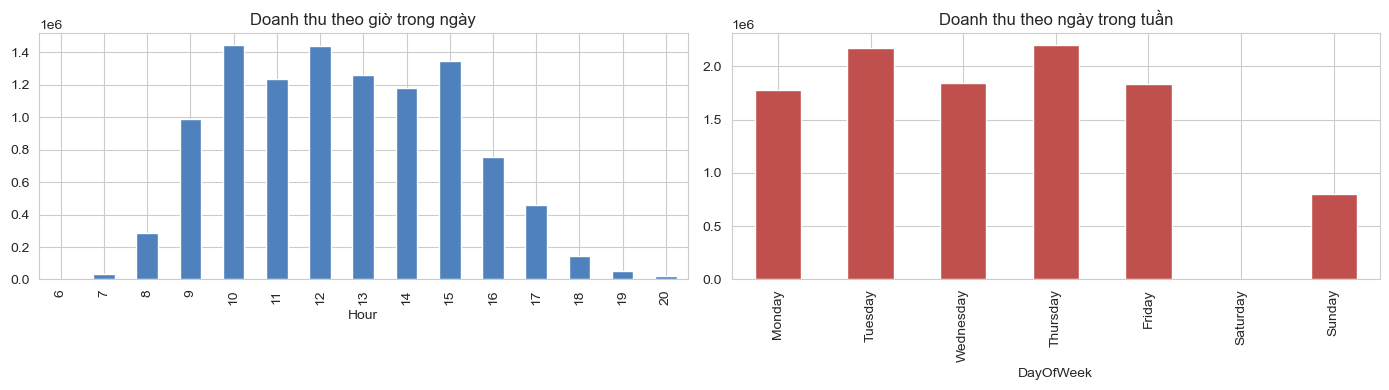

In [19]:
df_clean["Hour"] = df_clean.index.hour
df_clean["DayOfWeek"] = df_clean.index.day_name()

fig, axes = plt.subplots(1, 2, figsize=(14,4))
df_clean.groupby("Hour")["Revenue"].sum().plot(kind="bar", ax=axes[0], color="#4f81bd")
axes[0].set_title("Doanh thu theo giờ trong ngày")

order_days = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
df_clean.groupby("DayOfWeek")["Revenue"].sum().reindex(order_days).plot(kind="bar", ax=axes[1], color="#c0504d")
axes[1].set_title("Doanh thu theo ngày trong tuần")
plt.tight_layout()
plt.show()

df_clean = df_clean.reset_index()

**Nhận xét:**
- Doanh thu có xu hướng **tăng dần về cuối năm** (tháng 9–11/2011), phù hợp với mùa mua sắm cuối năm/lễ hội — dữ liệu có tính **thời vụ (seasonality)** rõ rệt.
- Không có giao dịch vào **Thứ Bảy** (đặc điểm vận hành của công ty) — cần lưu ý khi resample theo tuần/ngày cho các mô hình chuỗi thời gian.
- Giờ giao dịch tập trung trong khung giờ hành chính (khoảng 10h–15h).

## 6. Phân tích theo quốc gia

In [20]:
country_stats = df_clean.groupby("Country").agg(
    Revenue=("Revenue","sum"),
    Orders=("InvoiceNo","nunique"),
    Customers=("CustomerID","nunique")
).sort_values("Revenue", ascending=False)

country_stats.head(10)

,Revenue,Orders,Customers
Country,,,
United Kingdom,9001744.094,18019,3920
Netherlands,285446.340,94,9
EIRE,283140.520,288,3
Germany,228678.400,457,94
France,209625.370,392,87
Australia,138453.810,57,9
Spain,61558.560,90,30
Switzerland,57067.600,54,21
Belgium,41196.340,98,25


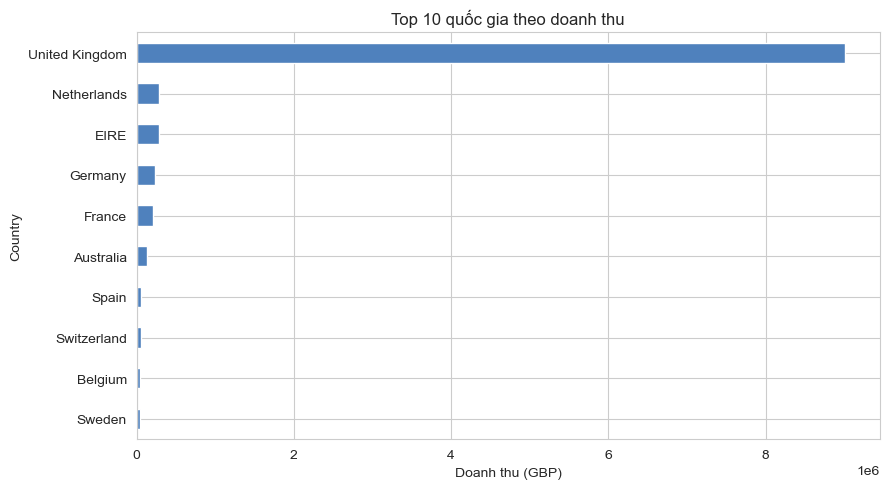

Thị phần doanh thu của United Kingdom: 84.6%


In [21]:
top10 = country_stats.head(10)
fig, ax = plt.subplots(figsize=(9,5))
top10["Revenue"].sort_values().plot(kind="barh", ax=ax, color="#4f81bd")
ax.set_title("Top 10 quốc gia theo doanh thu")
ax.set_xlabel("Doanh thu (GBP)")
plt.tight_layout()
plt.show()

uk_share = country_stats.loc["United Kingdom","Revenue"] / country_stats["Revenue"].sum() * 100
print(f"Thị phần doanh thu của United Kingdom: {uk_share:.1f}%")

**Nhận xét:**
- Doanh thu tập trung áp đảo tại **United Kingdom** — đây là thị trường chủ lực, các quốc gia khác chỉ chiếm phần nhỏ.
- Khi phân tích/so sánh giữa các quốc gia, cần lưu ý sự mất cân bằng dữ liệu rất lớn giữa UK và phần còn lại.

## 7. Phân tích theo sản phẩm

In [22]:
product_stats = df_clean.groupby(["StockCode","Description"]).agg(
    Quantity=("Quantity","sum"),
    Revenue=("Revenue","sum"),
    Orders=("InvoiceNo","nunique")
).sort_values("Revenue", ascending=False)

product_stats.head(10)

,,Quantity,Revenue,Orders
StockCode,Description,,,
DOT,DOTCOM POSTAGE,706,206248.77,706
22423,REGENCY CAKESTAND 3 TIER,13851,174156.54,1988
23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1
85123A,WHITE HANGING HEART T-LIGHT HOLDER,37580,104284.24,2189
47566,PARTY BUNTING,18283,99445.23,1685
85099B,JUMBO BAG RED RETROSPOT,48371,94159.81,2089
23166,MEDIUM CERAMIC TOP STORAGE JAR,78033,81700.92,247
POST,POSTAGE,3150,78101.88,1126
M,Manual,6984,77750.27,289


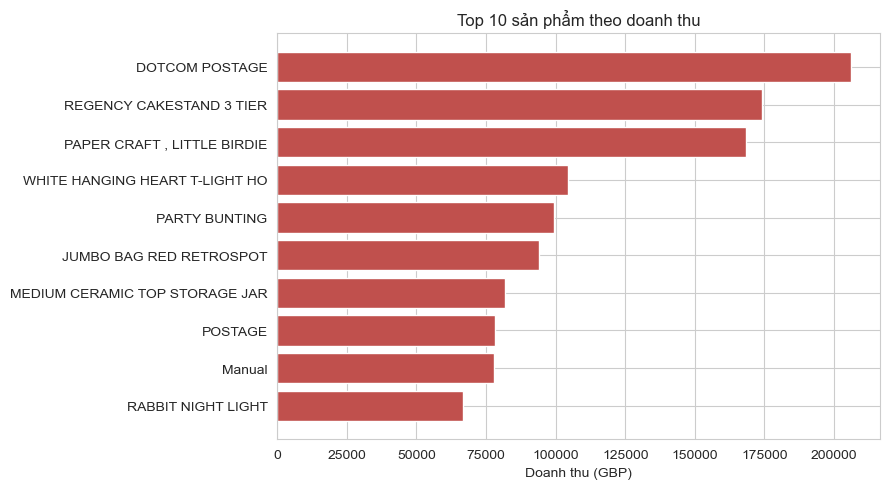

In [23]:
top_products = product_stats.head(10).reset_index()
fig, ax = plt.subplots(figsize=(9,5))
ax.barh(top_products["Description"].str[:30], top_products["Revenue"], color="#c0504d")
ax.invert_yaxis()
ax.set_title("Top 10 sản phẩm theo doanh thu")
ax.set_xlabel("Doanh thu (GBP)")
plt.tight_layout()
plt.show()

## 8. Phân tích theo khách hàng

In [24]:
df_cust = df_clean.dropna(subset=["CustomerID"]).copy()
print(f"Số khách hàng duy nhất: {df_cust['CustomerID'].nunique()}")

customer_stats = df_cust.groupby("CustomerID").agg(
    Revenue=("Revenue","sum"),
    Orders=("InvoiceNo","nunique"),
    LastPurchase=("InvoiceDate","max"),
    FirstPurchase=("InvoiceDate","min")
)
customer_stats["AvgOrderValue"] = customer_stats["Revenue"] / customer_stats["Orders"]
customer_stats.sort_values("Revenue", ascending=False).head(10)

Số khách hàng duy nhất: 4338


,Revenue,Orders,LastPurchase,FirstPurchase,AvgOrderValue
CustomerID,,,,,
14646.0,280206.02,73,2011-12-08 12:12:00,2010-12-20 10:09:00,3838.438630
18102.0,259657.30,60,2011-12-09 11:50:00,2010-12-07 16:42:00,4327.621667
17450.0,194390.79,46,2011-12-01 13:29:00,2010-12-07 09:23:00,4225.886739
16446.0,168472.50,2,2011-12-09 09:15:00,2011-05-18 09:52:00,84236.250000
14911.0,143711.17,201,2011-12-08 15:54:00,2010-12-01 14:05:00,714.980945
12415.0,124914.53,21,2011-11-15 14:22:00,2011-01-06 11:12:00,5948.310952
14156.0,117210.08,55,2011-11-30 10:54:00,2010-12-03 11:48:00,2131.092364
17511.0,91062.38,31,2011-12-07 10:12:00,2010-12-01 10:19:00,2937.496129
16029.0,80850.84,63,2011-11-01 10:27:00,2010-12-01 09:57:00,1283.346667


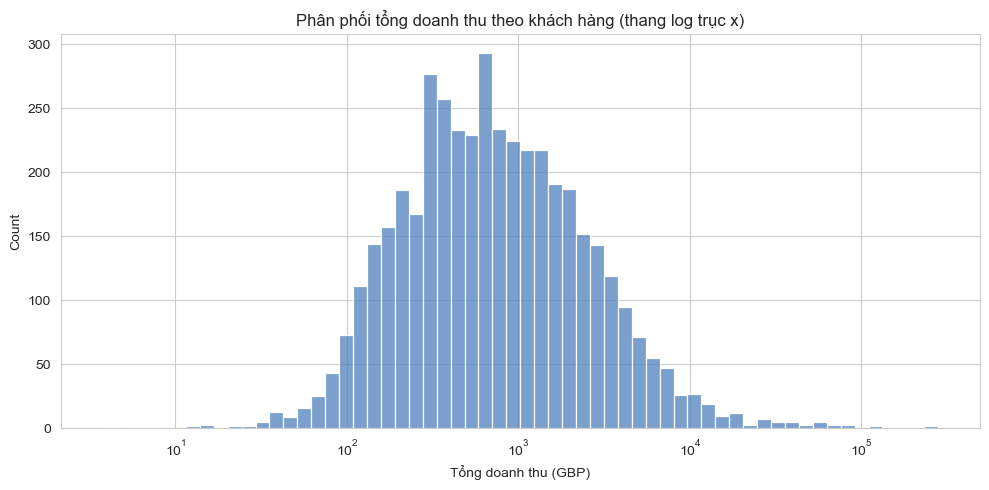

Top 20% khách hàng đóng góp 74.7% tổng doanh thu


In [25]:
fig, ax = plt.subplots()
sns.histplot(customer_stats["Revenue"], bins=60, log_scale=(True, False), ax=ax, color="#4f81bd")
ax.set_title("Phân phối tổng doanh thu theo khách hàng (thang log trục x)")
ax.set_xlabel("Tổng doanh thu (GBP)")
plt.tight_layout()
plt.show()

top_20pct_n = int(len(customer_stats)*0.2)
top20_revenue_share = customer_stats.sort_values("Revenue", ascending=False).head(top_20pct_n)["Revenue"].sum() / customer_stats["Revenue"].sum() * 100
print(f"Top 20% khách hàng đóng góp {top20_revenue_share:.1f}% tổng doanh thu")

**Nhận xét:**
- Doanh thu theo khách hàng cũng lệch phải mạnh, tuân theo nguyên lý **Pareto (80/20)**: một nhóm nhỏ khách hàng đóng góp phần lớn doanh thu — phù hợp để triển khai phân khúc **RFM (Recency, Frequency, Monetary)** cho các phân tích sâu hơn.

## 9. Tổng kết insight chính

1. **Chất lượng dữ liệu:** ~25% dòng thiếu `CustomerID`; có ~9,288 giao dịch hủy (`InvoiceNo` bắt đầu bằng "C") cần loại khi phân tích doanh số bán ra thực tế.
2. **Phân phối lệch phải mạnh** ở `Quantity`, `UnitPrice`, `Revenue` — cân nhắc log-transform hoặc xử lý outlier khi mô hình hóa.
3. **Tính thời vụ rõ rệt:** doanh thu tăng mạnh về cuối năm (mùa lễ hội); không có giao dịch vào Thứ Bảy — cần lưu ý khi xây dựng chuỗi thời gian (time series) cho dự báo.
4. **Tập trung địa lý:** United Kingdom chiếm phần lớn doanh thu — các thị trường khác có dữ liệu thưa.
5. **Tập trung khách hàng (Pareto):** một tỷ lệ nhỏ khách hàng đóng góp phần lớn doanh thu — tiềm năng cho phân khúc khách hàng (RFM/CLV).

**Gợi ý hướng phân tích tiếp theo:**
- Xây dựng chuỗi thời gian doanh thu (theo ngày/tuần) để dự báo (SARIMA/SARIMAX/Prophet).
- Phân khúc khách hàng bằng RFM và clustering (K-Means).
- Market basket analysis (association rules) để tìm sản phẩm hay được mua kèm nhau.